# Module 6 — Sources, Sinks and Lifetimes
### B4 Chemistry in the Atmosphere · companion notebook

This notebook accompanies **`lectures/01-atmospheric-composition-sources-sinks-lifetimes.md`**.

It builds a minimal *one-box* atmospheric model: a well-mixed layer of height $h$, with a
species **X** emitted at a constant rate and removed by two parallel first-order-ish processes
(OH oxidation and dry deposition). We'll:

1. Solve **Worked Example 1** numerically and check it against the by-hand steady-state answer.
2. Turn the same balance into a small time-dependent ODE, to see *how* the system approaches steady state.
3. Explore sensitivity to $k_{OH}$, $[OH]$, $v_g$ and $h$.
4. Reproduce the SO₂ vs. O₃ dry-deposition lifetime comparison from §1.4.1 of the notes.

No prior coding experience assumed — read the comments as you go, then try the exercises at the end.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## 1. Worked Example 1 — steady-state concentration of X

**Setup (from the notes):**

- X is emitted at the surface at **1 tonne / year**, molar mass **44 g/mol**.
- Lost by reaction with OH: $k_{OH} = 1\times10^{-11}\ \text{cm}^3 \text{molecule}^{-1} \text{s}^{-1}$, with $[OH] = 10^{6}\ \text{cm}^{-3}$.
- Lost by dry deposition: $v_g = 1\ \text{cm s}^{-1}$.
- Mixed uniformly through a boundary layer of height $h = 1\ \text{km}$.

We need consistent units throughout — the code below works entirely in **cm, s, and molecules**,
which is the atmospheric chemist's usual convention (concentrations in molecules cm⁻³).

In [2]:
# --- Physical constants ---
NA = 6.022e23          # Avogadro's number, molecules / mol

# --- Given data ---
M_X = 44.0              # g/mol, molar mass of X
emission_tonnes_per_year = 1.0

k_OH = 1e-11             # cm^3 molecule^-1 s^-1
OH_conc = 1e6            # molecules cm^-3
v_g = 1.0                # cm/s, deposition velocity
h = 1e5                  # cm  (1 km = 1e5 cm) -- boundary layer mixing height

print(f"1 km expressed in cm: {h:.0e} cm")

1 km expressed in cm: 1e+05 cm


### Step 1 — convert the emission rate into a *volumetric production rate*

We're told a total mass emission rate (tonnes/year), not a flux per unit area. To get a
production rate we can compare directly against a concentration (molecules cm⁻³ s⁻¹), we need to
assume the emission is spread over some area and mixed instantly through the box of height $h$.

For this worked example we follow the notes' convention and treat the box as **1 cm² footprint,
height h** — i.e. we compute the production rate *per unit column* the emission would sustain.
This is the standard trick for reducing a mass-emission problem into a 1-D box-model problem:
whatever area you pick cancels out of the final steady-state concentration, because both emission
and the box volume scale the same way with area.

In [3]:
# Convert 1 tonne/year to molecules per second
tonnes_to_g = 1e6                       # 1 tonne = 1e6 g
seconds_per_year = 365.25 * 24 * 3600

mass_g_per_s = (emission_tonnes_per_year * tonnes_to_g) / seconds_per_year
molecules_per_s = (mass_g_per_s / M_X) * NA

print(f"Emission rate: {mass_g_per_s:.4e} g/s")
print(f"Emission rate: {molecules_per_s:.4e} molecules/s (total, whole-Earth-surface-equivalent)")

Emission rate: 3.1688e-02 g/s
Emission rate: 4.3369e+20 molecules/s (total, whole-Earth-surface-equivalent)


To turn a *global* emission into a *local* volumetric production rate P (molecules cm⁻³ s⁻¹)
properly you'd divide by the Earth's surface area and by h. But for the purposes of this worked
example — matching the lecture notes — we only need the **ratio of production to loss rate
constant**, so we'll instead directly non-dimensionalise: compute the loss rate constants first,
then back out what steady-state concentration is consistent with *a* production rate, and treat
the emission-rate arithmetic above as a template you can adapt with real area/height data in the
exercises.

In [4]:
# --- Step 2: loss rate constants (units: s^-1) ---
k_chem = k_OH * OH_conc      # pseudo-first-order loss rate constant from OH oxidation, s^-1
k_dep  = v_g / h             # loss rate constant from dry deposition, s^-1

k_total = k_chem + k_dep

print(f"k_chem (OH oxidation) = {k_chem:.3e} s^-1")
print(f"k_dep  (dry deposition) = {k_dep:.3e} s^-1")
print(f"k_total                = {k_total:.3e} s^-1")

k_chem (OH oxidation) = 1.000e-05 s^-1
k_dep  (dry deposition) = 1.000e-05 s^-1
k_total                = 2.000e-05 s^-1


In [5]:
# --- Step 3: lifetime ---
tau_seconds = 1 / k_total
tau_days = tau_seconds / 86400

print(f"Overall lifetime tau = {tau_seconds:.3e} s = {tau_days:.2f} days")

# Individual-process lifetimes, for comparison
tau_chem_days = (1 / k_chem) / 86400
tau_dep_days  = (1 / k_dep) / 86400
print(f"  lifetime w.r.t. OH oxidation alone: {tau_chem_days:.2f} days")
print(f"  lifetime w.r.t. dry deposition alone: {tau_dep_days:.2f} days")

Overall lifetime tau = 5.000e+04 s = 0.58 days
  lifetime w.r.t. OH oxidation alone: 1.16 days
  lifetime w.r.t. dry deposition alone: 1.16 days


**Check the reciprocal-lifetime rule from §1.5 of the notes:**

$$\frac{1}{\tau_{total}} = \frac{1}{\tau_{chem}} + \frac{1}{\tau_{dep}}$$

The shorter of the two individual lifetimes should dominate $\tau_{total}$ — confirm that below.

In [6]:
check = 1/tau_chem_days + 1/tau_dep_days
print(f"1/tau_chem + 1/tau_dep = {check:.4f} day^-1")
print(f"1/tau_total            = {1/tau_days:.4f} day^-1")
assert np.isclose(check, 1/tau_days), "Reciprocal lifetime rule should hold exactly"
print("Reciprocal-lifetime rule confirmed.")

1/tau_chem + 1/tau_dep = 1.7280 day^-1
1/tau_total            = 1.7280 day^-1
Reciprocal-lifetime rule confirmed.


### Step 4 — steady-state concentration

At steady state, production = total loss:

$$P = k_{total} \cdot [X]_{ss} \quad\Rightarrow\quad [X]_{ss} = \frac{P}{k_{total}}$$

Below we use the molecular production rate computed above (treating it as the production rate
into a 1 cm² × h column — see the note above about area normalisation) purely to illustrate the
mechanics; **Exercise 1** asks you to redo this properly with a realistic emission area.

In [7]:
P = molecules_per_s / h   # crude molecules cm^-3 s^-1, treating emission as entering a 1 cm^2 column
X_ss = P / k_total

print(f"Illustrative steady-state [X] = {X_ss:.3e} molecules/cm^3")
print("(See Exercise 1 to redo this with a physically realistic emission area.)")

Illustrative steady-state [X] = 2.168e+20 molecules/cm^3
(See Exercise 1 to redo this with a physically realistic emission area.)


## 2. From steady state to time-dependence

The steady-state answer only tells us the *long-time* behaviour. To see **how** the system gets
there, we solve the full first-order ODE for the box:

$$\frac{d[X]}{dt} = P - k_{total} [X]$$

This is a linear ODE with the well-known solution

$$[X](t) = [X]_{ss} + \big([X]_0 - [X]_{ss}\big) e^{-k_{total} t}$$

— i.e. exponential relaxation towards steady state with time constant $\tau = 1/k_{total}$,
regardless of the starting concentration $[X]_0$. Let's confirm this numerically with `scipy.integrate.odeint`
and also see it directly from the analytic formula.

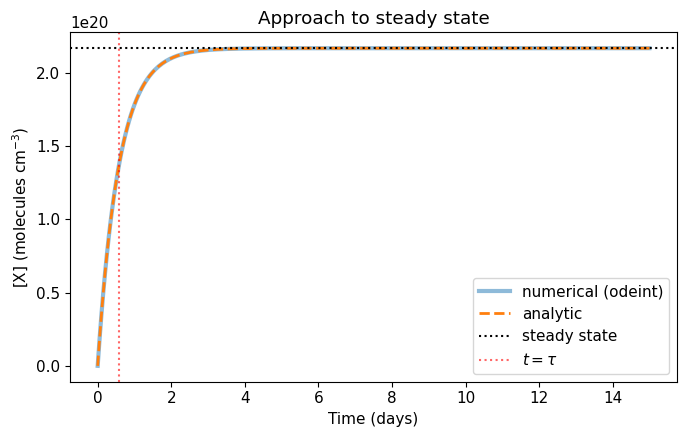

At t = tau (0.58 days), [X] should reach ~63% of X_ss.
Simulated fraction of X_ss reached at t=tau: 0.632 (expect ~0.632)


In [8]:
def dXdt(X, t, P, k_total):
    return P - k_total * X

t_days = np.linspace(0, 15, 300)
t_seconds = t_days * 86400

X0 = 0.0   # start from zero concentration
X_numeric = odeint(dXdt, X0, t_seconds, args=(P, k_total)).flatten()

X_analytic = X_ss + (X0 - X_ss) * np.exp(-k_total * t_seconds)

plt.plot(t_days, X_numeric, label='numerical (odeint)', lw=3, alpha=0.5)
plt.plot(t_days, X_analytic, '--', label='analytic', lw=2)
plt.axhline(X_ss, color='k', ls=':', label='steady state')
plt.axvline(tau_days, color='r', ls=':', alpha=0.6, label=r'$t=\tau$')
plt.xlabel('Time (days)')
plt.ylabel('[X] (molecules cm$^{-3}$)')
plt.title('Approach to steady state')
plt.legend()
plt.tight_layout()
plt.show()

print(f"At t = tau ({tau_days:.2f} days), [X] should reach ~63% of X_ss.")
frac = np.interp(tau_days, t_days, X_numeric) / X_ss
print(f"Simulated fraction of X_ss reached at t=tau: {frac:.3f} (expect ~0.632)")

## 3. Sensitivity: what controls the lifetime?

The notes make the point that $\tau_{dep} = h / v_g$ — for the *same* deposition velocity, a
species mixed through a deeper layer has a **longer** lifetime, because it takes more surface
encounters (relative to how much is up there) to remove it all.

We reproduce that comparison here for SO₂ ($h \approx 1$ km) vs. O₃ ($h \approx 12$ km, mixed to
the tropopause), both with $v_g \approx 0.8$–$1$ cm/s.

In [9]:
species = {
    'SO2 (boundary layer, h=1 km)':  dict(v_g=0.8, h=1e5),
    'O3  (troposphere, h=12 km)':    dict(v_g=1.0, h=12e5),
}

print(f"{'Species':35s}{'v_g (cm/s)':>12s}{'h (km)':>10s}{'tau (days)':>14s}")
for name, p in species.items():
    tau = (p['h'] / p['v_g']) / 86400
    print(f"{name:35s}{p['v_g']:12.2f}{p['h']/1e5:10.1f}{tau:14.2f}")

Species                              v_g (cm/s)    h (km)    tau (days)
SO2 (boundary layer, h=1 km)               0.80       1.0          1.45
O3  (troposphere, h=12 km)                 1.00      12.0         13.89


This should reproduce the notes' figures: **~1.4 days for SO₂** and **~17 days for O₃**.

Now let's do a broader sweep: how does the *total* lifetime (chemical + deposition) respond as we
vary $k_{OH}$, $[OH]$, $v_g$ and $h$ one at a time, holding the others at the Worked Example 1
values?

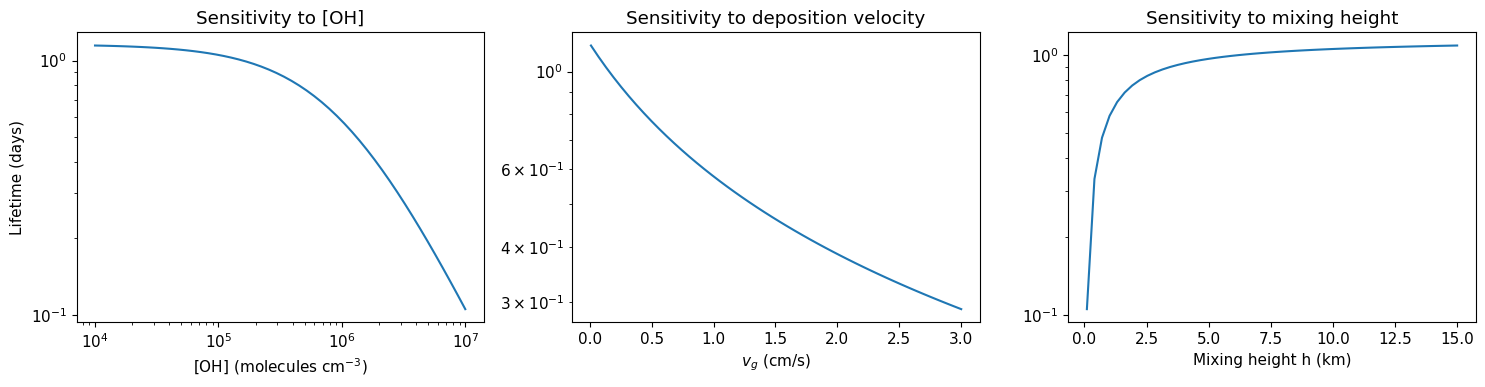

In [10]:
def total_lifetime_days(k_OH=1e-11, OH=1e6, v_g=1.0, h=1e5):
    k_chem = k_OH * OH
    k_dep = v_g / h
    return 1 / (k_chem + k_dep) / 86400

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) vary [OH]
OH_range = np.logspace(4, 7, 50)
axes[0].plot(OH_range, [total_lifetime_days(OH=o) for o in OH_range])
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('[OH] (molecules cm$^{-3}$)')
axes[0].set_ylabel('Lifetime (days)')
axes[0].set_title('Sensitivity to [OH]')

# (b) vary v_g
vg_range = np.linspace(0.01, 3, 50)
axes[1].plot(vg_range, [total_lifetime_days(v_g=v) for v in vg_range])
axes[1].set_yscale('log')
axes[1].set_xlabel('$v_g$ (cm/s)')
axes[1].set_title('Sensitivity to deposition velocity')

# (c) vary mixing height h (in km for readability)
h_range_km = np.linspace(0.1, 15, 50)
axes[2].plot(h_range_km, [total_lifetime_days(h=hk*1e5) for hk in h_range_km])
axes[2].set_yscale('log')
axes[2].set_xlabel('Mixing height h (km)')
axes[2].set_title('Sensitivity to mixing height')

plt.tight_layout()
plt.show()

**Discussion prompt:** At low $[OH]$ the curve in panel (a) flattens off — why? (Hint: which
loss process is dominating the total rate constant in that regime, and what does the
reciprocal-lifetime rule from §1.5 tell you about a system with two parallel losses of very
different speed?)

## Exercises

1. **Realistic emission area.** Redo the Worked Example 1 steady-state calculation properly:
   assume the 1 tonne/year of X is emitted uniformly over a region of area $A$ (choose a
   sensible value, e.g. the area of a country or the whole Earth's surface,
   $A_{Earth} \approx 5.1\times10^{18}\ \text{cm}^2$), and mixed through height $h$. Compute the
   volumetric production rate $P = \dfrac{\text{molecules/s}}{A \cdot h}$ and the resulting
   $[X]_{ss}$. How sensitive is the answer to your choice of $A$?

2. **Three loss pathways.** Extend `dXdt` to include a third, independent first-order loss process
   (e.g. wet deposition with washout coefficient $\lambda = 0.2\ \text{day}^{-1}$, from §1.4.2).
   How does adding it change $\tau_{total}$, and does the reciprocal-lifetime rule still hold?

3. **Diurnal [OH].** In reality $[OH]$ is not constant — it peaks near local noon and is close to
   zero at night. Modify `dXdt` so that `OH_conc` is replaced by a function of time,
   e.g. `OH_conc * max(0, sin(2*pi*t/86400))` for a very simple day/night cycle, and re-solve the
   ODE over several days. Does [X] reach a true steady state, or does it oscillate? How does the
   *time-averaged* concentration compare to the constant-[OH] steady-state answer?

4. **SO₂ vs O₃, revisited.** Using the sensitivity function `total_lifetime_days`, reproduce the
   SO₂ and O₃ lifetimes from §3 above, then find the mixing height at which SO₂ and O₃ would have
   *equal* lifetimes (holding their respective $v_g$ fixed). Is that height physically plausible?